In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from scipy.ndimage import gaussian_filter
import MDAnalysis as md
import matplotlib
import pandas as pd
import seaborn as sns
matplotlib.rcParams['pdf.fonttype'] = 42

# functions
def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


def get_color_gradient3(c1, c2, c3, n):
    """
    Given three hex colors, returns a color gradient
    with n colors.
    """
    assert n > 2
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    c3_rgb = np.array(hex_to_RGB(c3))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors1 = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    rgb_colors2 = [((1-mix)*c2_rgb + (mix*c3_rgb)) for mix in mix_pcts]
    rgb_colors = rgb_colors1+rgb_colors2
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]




from matplotlib.colors import LinearSegmentedColormap

path = '/Volumes/Elements/PTM_project/PIPS2/LongMD_400K/'

color1 = "#F8EDEB"
color3 = "#F49595"
num_points = 2000
grad = get_color_gradient(color1, color3, num_points)
cmap = LinearSegmentedColormap.from_list(name='test',colors=grad)

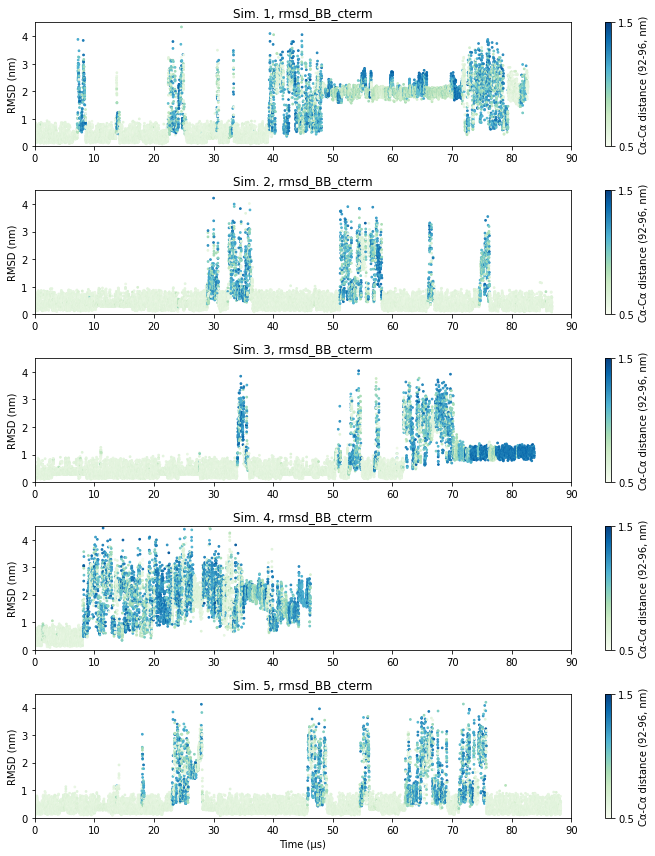

In [2]:

plt.figure(figsize = (10,12))
fontsize = 10

rmsd_type = 'rmsd_BB_cterm'

for sim in range(1,6):
    plt.subplot(5,1,sim)
    rmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
    SASA = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,2]
    time = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,0]/1e6 # us
    CV = np.loadtxt(path+'sim{}/COLVAR'.format(sim))
    time = time[::10]
    rmsd = rmsd[::10]
    SASA = SASA[::10]
    CV = CV[::10]


    sc = plt.scatter(time,rmsd,c = CV[:,2],cmap='GnBu',s=3, rasterized=True)
    plt.colorbar(sc,label = 'Cα-Cα distance (92-96, nm)',ticks=[0.5,1.5])
    plt.clim(0.5,1.5)
    plt.title('Sim. {}, {}'.format(sim, rmsd_type))
    if sim==5:
        plt.xlabel('Time (µs)',fontsize = fontsize)
    plt.ylabel('RMSD (nm)',fontsize = fontsize)
    plt.ylim(0,4.5)
    plt.xlim(0,90)

plt.tight_layout()
plt.savefig('{}_cacadist_time.pdf'.format(rmsd_type), dpi=300)




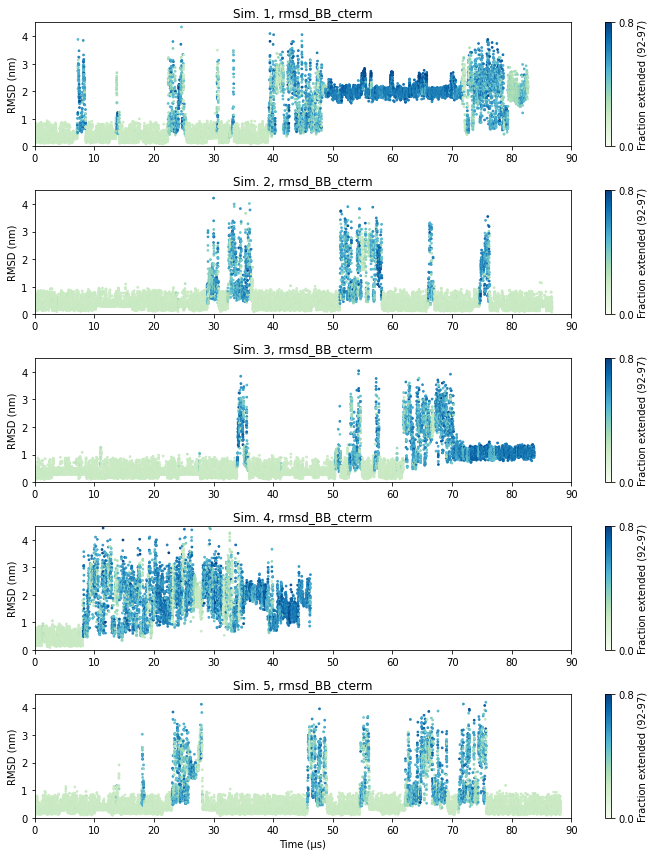

In [3]:

plt.figure(figsize = (10,12))
fontsize = 10

rmsd_type = 'rmsd_BB_cterm'

for sim in range(1,6):
    plt.subplot(5,1,sim)
    rmsd = np.loadtxt(path+'sim{}/{}.xvg'.format(sim, rmsd_type), skiprows=18)[:,1]
    SASA = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,2]
    time = np.loadtxt(path+'sim{}/sasa_SER96.xvg'.format(sim), skiprows=25)[:,0]/1e6 # us
    CV = np.loadtxt(path+'sim{}/COLVAR'.format(sim))
    time = time[::10]
    rmsd = rmsd[::10]
    SASA = SASA[::10]
    CV = CV[::10]


    sc = plt.scatter(time,rmsd,c = CV[:,1],cmap='GnBu',s=3, rasterized=True)
    plt.colorbar(sc,label = 'Fraction extended (92-97)',ticks=[0,0.8])
    plt.clim(0,0.8)
    plt.title('Sim. {}, {}'.format(sim, rmsd_type))
    if sim==5:
        plt.xlabel('Time (µs)',fontsize = fontsize)
    plt.ylabel('RMSD (nm)',fontsize = fontsize)
    plt.ylim(0,4.5)
    plt.xlim(0,90)

plt.tight_layout()
plt.savefig('{}_dihrmsd_time.pdf'.format(rmsd_type), dpi=300)



